In [20]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow_datasets as tfds

In [ ]:
mnist_dataset,mnist_info = tfds.load(name='mnist',with_info=True,as_supervised=True)
mnist_train , mnist_test = mnist_dataset['train'] , mnist_dataset['test']

num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples,tf.int64)
num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples,tf.int64)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.P2MQ5K_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.P2MQ5K_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [21]:
def scale(image,label):
  image = tf.cast(image, tf.float32)
  image /= 255.
  return image , label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)


In [22]:
BUFFER_SIZE = 1000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)
validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

In [23]:
BATCH_SIZE = 100

train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

validation_inputs, validation_targets = next(iter(validation_data))
print(validation_inputs.shape , validation_targets.shape)

(6000, 28, 28, 1) (6000,)


In [28]:
input_size = 784
output_size = 10

hidden_layer_size = 100

#----------------
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(hidden_layer_size,activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size,activation='relu'),
    tf.keras.layers.Dense(output_size,activation='softmax')
])

model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [29]:
NUM_EPOCHS = 30

early_stopping = tf.keras.callbacks.EarlyStopping(patience=2)

model.fit(train_data,
          epochs = NUM_EPOCHS,
          callbacks = [early_stopping],
          validation_data = (validation_inputs,validation_targets),
          verbose = 1
          )

Epoch 1/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9019 - loss: 0.3436 - val_accuracy: 0.9490 - val_loss: 0.1815
Epoch 2/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9586 - loss: 0.1400 - val_accuracy: 0.9623 - val_loss: 0.1308
Epoch 3/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9716 - loss: 0.0963 - val_accuracy: 0.9628 - val_loss: 0.1220
Epoch 4/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9778 - loss: 0.0744 - val_accuracy: 0.9693 - val_loss: 0.1051
Epoch 5/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9814 - loss: 0.0600 - val_accuracy: 0.9678 - val_loss: 0.1061
Epoch 6/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9854 - loss: 0.0469 - val_accuracy: 0.9717 - val_loss: 0.0977
Epoch 7/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9880 - loss: 0.0383 - val_accuracy: 0.9727 - val_loss: 0.0959
Epoch 8/30
540/540 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9901 - loss: 0.0322 - val_accuracy: 0.

In [30]:
test_loss , test_accuracy = model.evaluate(test_data)
print('Test loss: {0:.2f}. Test accuracy: {1:.2f}%'.format(test_loss, test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9760 - loss: 0.0886
Test loss: 0.09. Test accuracy: 97.60%


Wykryto jasne tło - odwrócono kolory.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


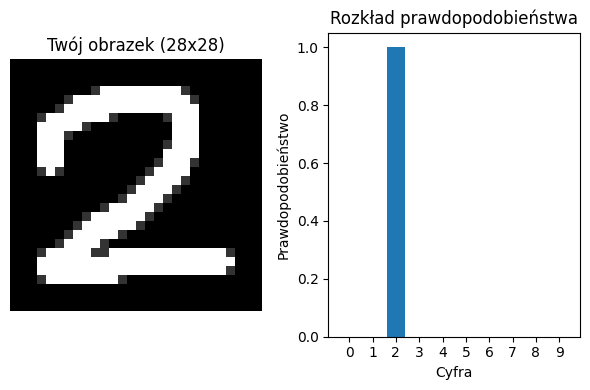


Model przewiduje: cyfra 2
Pewność: 100.00%

Prawdopodobieństwa dla wszystkich cyfr:
  Cyfra 0: 0.00%
  Cyfra 1: 0.00%
  Cyfra 2: 100.00%
  Cyfra 3: 0.00%
  Cyfra 4: 0.00%
  Cyfra 5: 0.00%
  Cyfra 6: 0.00%
  Cyfra 7: 0.00%
  Cyfra 8: 0.00%
  Cyfra 9: 0.00%


In [33]:

IMAGE_PATH = 'test_2.png'


img = cv2.imread(IMAGE_PATH)

if img is None:
    print("Nie znaleziono pliku! Upewnij się, że plik jest wgrany do Colab.")
else:
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if np.mean(img_gray) > 127:
        img_gray = cv2.bitwise_not(img_gray)
        print("Wykryto jasne tło - odwrócono kolory.")


    img_resized = cv2.resize(img_gray, (28, 28))


    img_normalized = img_resized.astype('float32') / 255.0


    img_input = img_normalized.reshape(1, 28, 28, 1)


    predictions = model.predict(img_input)
    predicted_digit = np.argmax(predictions[0])
    confidence = predictions[0][predicted_digit] * 100

    plt.figure(figsize=(6, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_resized, cmap='gray')
    plt.title('Twój obrazek (28x28)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.bar(range(10), predictions[0])
    plt.xticks(range(10))
    plt.xlabel('Cyfra')
    plt.ylabel('Prawdopodobieństwo')
    plt.title('Rozkład prawdopodobieństwa')

    plt.tight_layout()
    plt.show()

    print(f'\nModel przewiduje: cyfra {predicted_digit}')
    print(f'Pewność: {confidence:.2f}%')
    print(f'\nPrawdopodobieństwa dla wszystkich cyfr:')
    for i, prob in enumerate(predictions[0]):
        print(f'  Cyfra {i}: {prob*100:.2f}%')